## The 2D Ising Model Near Criticality

We study the two–dimensional Ising model on a square lattice close to its critical temperature.
The main goal is to compare two Monte Carlo update schemes:

- Metropolis (local single–spin flips)
- Swendsen–Wang (non–local cluster flips)

Both algorithms sample the same equilibrium distribution, so time-averaged observables agree.
The relevant difference is how fast the Markov chain decorrelates, especially near the critical point,
where local updates suffer from critical slowing down.

In this notebook we will:
1. define the model and observables,
2. implement both update algorithms,
3. compare them by time series, snapshots, and (most importantly) autocorrelation times.

In [3]:
import time
import numpy as np
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

## The 2D Ising Model

We consider spins $\sigma_i \in \{-1,+1\}$ on a $L_x\times L_y$ square lattice with periodic boundary conditions.

The Hamiltonian is
$$
H(\sigma) = -J\sum_{\langle ij\rangle}\sigma_i\sigma_j - h\sum_i\sigma_i,
$$
and the Boltzmann weight is
$$
P(\sigma)\propto e^{-\beta H(\sigma)}, \qquad \beta=\frac{1}{T}.
$$

For the 2D Ising model at $h=0$ the critical temperature is known exactly:
$$
T_c = \frac{2}{\ln(1+\sqrt{2})}\approx 2.269.
$$

Close to $T_c$ the correlation length becomes large and local updates decorrelate slowly.
Cluster updates are designed to reduce this effect.
___

## Lattice geometry and lookup tables

We consider a square lattice of size $L_x\times L_y$ with periodic boundary conditions.  
Sites are labeled by a single index
$$
n(x,y)=xL_y+y,\qquad N=L_xL_y,
$$
so the spin configuration (the Monte Carlo state) is stored as a 1D array $\sigma\in\{-1,+1\}^N$.

To avoid recomputing neighbor indices during the simulation, we precompute two *static* geometry tables:

- Neighbor table `nbrs` of shape $(N,4)$: for each site $n$, `nbrs[n] = (right, left, down, up)`.  
  This is the “hopping table” used for fast local $\Delta E$ in Metropolis.

- Bond list `bonds` of shape $(2N,2)$: an edge list of nearest-neighbor pairs $(i,j)$, storing each undirected bond once (right + down).  

  This is convenient for sums over $\langle ij\rangle$ and for Swendsen–Wang bond activation on edges.

In [4]:
def build_bonds(Lx, Ly):
    N = Lx * Ly
    bonds = np.empty((2*N, 2), dtype=np.int32)
    k = 0
    for x in range(Lx):
        for y in range(Ly):
            n = x*Ly + y 
            bonds[k] = (n, x * Ly + ((y + 1) % Ly)); k += 1
            bonds[k] = (n, ((x + 1) % Lx) * Ly + y); k += 1
    return bonds

def build_neighbours(Lx: int, Ly: int) -> np.ndarray:
    N = Lx * Ly
    nbrs = np.empty((N, 4), dtype=np.int32)
    for x in range(Lx):
        for y in range(Ly):
            n = x * Ly + y
            nbrs[n, 0] = x * Ly + ((y + 1) % Ly)  # right
            nbrs[n, 1] = x * Ly + ((y - 1) % Ly)  # left
            nbrs[n, 2] = ((x + 1) % Lx) * Ly + y  # down
            nbrs[n, 3] = ((x - 1) % Lx) * Ly + y  # up
    return nbrs

## Observables

We measure energy and magnetization for each configuration.

Using the bond list `bonds` (each undirected bond once), the total energy is
$$
E(\sigma) = -J\sum_{(i,j)\in\texttt{bonds}}\sigma_i\sigma_j - h\sum_i\sigma_i.
$$
We also use the energy density $e = E/N$, where $N=L_xL_y$.

The magnetization is
$$
M=\sum_i \sigma_i,\qquad m = \frac{M}{N}.
$$
At $h=0$ and finite $N$, the $Z_2$ symmetry implies $\langle M\rangle \approx 0$ even below $T_c$,
because the Markov chain tunnels between the two magnetized phases. Therefore we also monitor $\langle |m|\rangle$
as a robust indicator of ordering.

### Response functions from fluctuations (per spin)

The specific heat and magnetic susceptibility can be obtained via fluctuation–dissipation relations:
$$
C_V = \frac{\beta^2}{N}\left(\langle E^2\rangle-\langle E\rangle^2\right),
\qquad
\chi = \frac{\beta}{N}\left(\langle M^2\rangle-\langle M\rangle^2\right).
$$
These are equilibrium properties, so both Metropolis and Swendsen–Wang must reproduce the same curves (within errors).

**Note.** Below $T_c$ and at $h=0$, the chain may switch between the two phases, which can affect how $M$-based
quantities behave. For diagnosing ordering we therefore always show $\langle |m|\rangle$ alongside $\chi$.

In [5]:
def measure(spins: np.ndarray, bonds: np.ndarray, J: float = 1.0, h: float = 0.0) -> dict:
    i = bonds[:, 0]
    j = bonds[:, 1]

    M = float(spins.sum())
    E = float(-J * np.sum(spins[i] * spins[j]) - h * M)

    N = spins.size
    m = M / N

    return {
        "E": E,
        "E2": E * E,
        "E_density": E / N,
        "M": M,
        "M2": M * M,
        "m": m,
        "abs_m": abs(m),
    }
    
def heat_capacity_from_series(E_raw: np.ndarray, beta: float, N: int) -> float:
    E = np.asarray(E_raw, dtype=float)
    return float((beta**2 / N) * ((E**2).mean() - E.mean()**2))

def susceptibility_from_series(M_raw: np.ndarray, beta: float, N: int) -> float:
    M = np.asarray(M_raw, dtype=float)
    return float((beta / N) * ((M**2).mean() - M.mean()**2))

def susceptibility_phase_fixed_from_series(M_raw: np.ndarray, absM_raw: np.ndarray, beta: float, N: int) -> float:
    M_raw = np.asarray(M_raw, dtype=float)
    absM_raw = np.asarray(absM_raw, dtype=float)
    return float((beta / N) * (np.mean(M_raw**2) - np.mean(absM_raw)**2))

## Utility functions (initial states + visualization)

Before implementing the Monte Carlo updates, we define a few small helpers:

- spin initialization,
- reshaping from 1D to 2D for plotting,
- compact snapshot plotting

In [6]:
def init_spins(N: int, rng: np.random.Generator, init: str = "random") -> np.ndarray:
    if init == "random":
        return rng.choice([-1, 1], size=N).astype(np.int8)
    if init == "ordered_plus":
        return np.ones(N, dtype=np.int8)
    if init == "ordered_minus":
        return -np.ones(N, dtype=np.int8)
    raise ValueError("init must be 'random', 'ordered_plus', or 'ordered_minus'")

def spins_to_2d(spins: np.ndarray, Lx: int, Ly: int) -> np.ndarray:
    return spins.reshape(Lx, Ly)

def plot_snapshots(snaps: list[np.ndarray], titles: list[str], Lx: int, Ly: int, suptitle: str = "") -> None:
    n = len(snaps)
    fig, axes = plt.subplots(1, n, figsize=(3.2 * n, 3.2), constrained_layout=True)
    if n == 1:
        axes = [axes]

    for ax, sp, title in zip(axes, snaps, titles):
        ax.imshow(spins_to_2d(sp, Lx, Ly), vmin=-1, vmax=1, interpolation="nearest")
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    if suptitle:
        fig.suptitle(suptitle)
    plt.show()
    
def plot_run_snapshots(run: dict, Lx: int, Ly: int, which: str = "init_therm", max_panels: int = 6) -> None:
    if not run.get("snapshots", None):
        raise ValueError("Run has no snapshots.")

    if which == "init_therm":
        snaps = [run["snapshots"]["init"], run["snapshots"]["after_therm"]]
        titles = ["init", "after therm"]
        plot_snapshots(snaps, titles, Lx, Ly, suptitle=f"{run['algo']}: init → therm (T={run['T']}, h={run.get('h',0.0)})")
        return

    if which == "init_therm_final":
        snaps = [run["snapshots"]["init"], run["snapshots"]["after_therm"], run["snapshots"]["final"]]
        titles = ["init", "after therm", "final"]
        plot_snapshots(snaps, titles, Lx, Ly, suptitle=f"{run['algo']}: init → therm → final (T={run['T']}, h={run.get('h',0.0)})")
        return

    if which == "meas":
        items = sorted(run.get("meas_snapshots", {}).items(), key=lambda x: x[0])[:max_panels]
        snaps = [sp for _, sp in items]
        titles = [f"t={t}" for t, _ in items]
        plot_snapshots(snaps, titles, Lx, Ly, suptitle=f"{run['algo']}: meas snapshots (T={run['T']}, h={run.get('h',0.0)})")
        return

    raise ValueError("which must be 'init_therm', 'init_therm_final', or 'meas'")

## Metropolis Monte Carlo (local update)

A Metropolis step proposes a local flip $\sigma_i \to -\sigma_i$.

For a site $i$, the energy change is
$$
\Delta E = 2\sigma_i\left(J\sum_{j\in nn(i)}\sigma_j + h\right).
$$

The proposal is accepted with probability
$$
P_{\mathrm{acc}}=\min\left(1, e^{-\beta \Delta E}\right).
$$

We define one Metropolis sweep as $N=L_xL_y$ such proposals.
This is a natural Monte Carlo time unit because, on average, each site is updated once per sweep.

In [7]:
def metropolis_sweep(spins: np.ndarray, nbrs: np.ndarray, beta: float, rng: np.random.Generator,
                     J: float = 1.0, h: float = 0.0) -> float:
    N = spins.size
    acc = 0

    for n in rng.permutation(N):
        s = spins[n]
        nn_sum = spins[nbrs[n]].sum()
        dE = 2.0 * s * (J * nn_sum + h)

        if dE <= 0.0 or rng.random() < np.exp(-beta * dE):
            spins[n] = -s
            acc += 1

    return acc / N

def run_metropolis(
    T: float, bonds: np.ndarray, nbrs: np.ndarray,
    n_therm: int, n_meas: int,
    init: str = "random", seed: int = 0,
    J: float = 1.0, h: float = 0.0, kB: float = 1.0,
    snapshot_at: tuple[int, ...] = (),
) -> dict:
    rng = np.random.default_rng(seed)
    beta = 1.0 / (kB * T)
    N = nbrs.shape[0]

    spins = init_spins(N, rng, init=init)

    snaps = {"init": spins.copy()}

    # thermalization
    for _ in range(n_therm):
        metropolis_sweep(spins, nbrs, beta, rng, J=J, h=h)
    snaps["after_therm"] = spins.copy()

    # measurement
    E = np.empty(n_meas)
    E_raw = np.empty(n_meas)
    M_raw = np.empty(n_meas)
    absM_raw = np.empty(n_meas)

    m = np.empty(n_meas)
    abs_m = np.empty(n_meas)
    acc = np.empty(n_meas)

    meas_snaps = {}
    snap_set = set(snapshot_at)

    t0 = time.perf_counter()
    for t in range(n_meas):
        acc[t] = metropolis_sweep(spins, nbrs, beta, rng, J=J, h=h)

        obs = measure(spins, bonds, J=J, h=h)

        E_raw[t] = obs["E"]
        M_raw[t] = obs["M"]
        E[t] = obs["E_density"]
        m[t] = obs["m"]
        abs_m[t] = obs["abs_m"]
        absM_raw[t] = abs(obs["M"])

        if t in snap_set:
            meas_snaps[t] = spins.copy()
    t1 = time.perf_counter()
    
    snaps["final"] = spins.copy()
    return {
        "algo": "metropolis",
        "T": float(T),
        "beta": float(beta),
        "init": init,
        "E": E,
        "m": m,
        "N": int(N),
        "E_raw": E_raw,
        "M_raw": M_raw,
        "absM_raw": absM_raw,
        "abs_m": abs_m,
        "acc": acc,
        "time_unit": "sweep",
        "snapshots": snaps,
        "meas_snapshots": meas_snaps,
        "wall_time_meas_s": float(t1 - t0),
        "n_meas": int(n_meas),
    }

## A single representative sanity run (low T vs high T)

We do one low-temperature and one high-temperature run:

- $T=1.5$ (ordered phase): $|m|$ close to 1, very low acceptance.
- $T=3.5$ (disordered phase): $|m|$ small, acceptance much higher.

This is not the "final physics"; it is a diagnostic that the code behaves sensibly

T=1.50  <E/N>=-1.952  <|m|>= 0.987  <acc>= 0.013


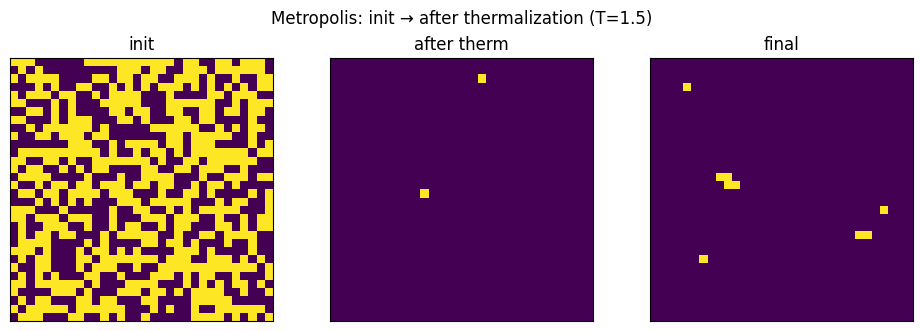

T=3.50  <E/N>=-0.658  <|m|>= 0.064  <acc>= 0.549


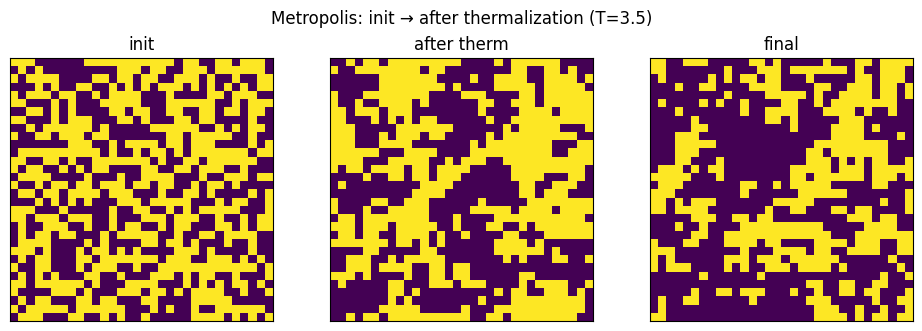

In [8]:
Lx = 32
Ly = 32
bonds = build_bonds(Lx, Ly)
nbrs  = build_neighbours(Lx, Ly)

for T in (1.5, 3.5):
    met = run_metropolis(
        T, bonds, nbrs,
        n_therm=2000, n_meas=2000,
        init="random", seed=0,
        snapshot_at=(0, 200, 800, 1999),
    )
    print(f"T={T:.2f}  <E/N>={met['E'].mean(): .3f}  <|m|>={met['abs_m'].mean(): .3f}  <acc>={met['acc'].mean(): .3f}")

    plot_snapshots(
        [met["snapshots"]["init"], met["snapshots"]["after_therm"], met["snapshots"]["final"]],
        ["init", "after therm", "final"],
        Lx, Ly,
        suptitle=f"Metropolis: init → after thermalization (T={T})",
    )

## Swendsen–Wang algorithm and the ghost-spin construction

The Swendsen–Wang (SW) algorithm is based on the Fortuin–Kasteleyn (FK) representation
of the Ising model.  
Instead of directly sampling spin configurations, one introduces auxiliary bond variables
that encode correlations between parallel spins.

For nearest neighbours $(i,j)$ we activate a bond with probability

$$
p_{\mathrm{nn}} = 1 - e^{-2\beta J},
$$

but only if $\sigma_i = \sigma_j$.
The activated bonds define a graph on the lattice.
Its connected components are clusters, and each cluster is flipped as a whole.

This construction satisfies detailed balance because
the joint spin–bond distribution reproduces the Boltzmann weight after summing over bonds.
Cluster flips then correspond to symmetry operations of this joint measure.

---

### Why the ghost spin is needed for $h \neq 0$

At zero field, the Hamiltonian is invariant under the global symmetry

$$
\sigma_i \rightarrow -\sigma_i.
$$

Therefore flipping a cluster with probability $1/2$ preserves detailed balance.

For $h \neq 0$ this symmetry is broken:
$
H(\sigma) \neq H(-\sigma),
$
so naive cluster flips would bias the sampling.

The ghost-spin trick restores the FK structure in the presence of a field:

- introduce one additional node $g$,
- connect spins aligned with the field to $g$ with probability

$$
p_{\mathrm{g}} = 1 - e^{-2\beta |h|}.
$$

Clusters connected to the ghost node represent spins energetically favored by the field.
They are not flipped.
All other clusters are flipped with probability $1/2$.

This construction reproduces the correct Boltzmann weight including the term
$-h\sum_i \sigma_i$ and therefore preserves detailed balance.

In [9]:
def sw_update_with_ghost(spins, bonds, beta, rng, J=1.0, h=0.0, return_details=False):
    N = spins.size
    p_nn = 1.0 - np.exp(-2.0 * beta * J)

    i = bonds[:, 0]
    j = bonds[:, 1]

    parallel = (spins[i] == spins[j])
    active_nn = parallel & (rng.random(size=bonds.shape[0]) < p_nn)

    if h == 0.0:
        active_g = np.zeros(N, dtype=bool)
        p_g = 0.0
    else:
        p_g = 1.0 - np.exp(-2.0 * beta * abs(h))
        sgn = 1 if h > 0 else -1
        align = (spins == sgn)
        active_g = align & (rng.random(size=N) < p_g)

    rows = i[active_nn]
    cols = j[active_nn]
    data = np.ones(rows.size, dtype=np.int8)

    if active_g.any():
        gi = np.nonzero(active_g)[0]
        rows = np.concatenate([rows, gi])
        cols = np.concatenate([cols, np.full(gi.size, N, dtype=np.int32)])
        data = np.concatenate([data, np.ones(gi.size, dtype=np.int8)])

    A = csr_matrix((data, (rows, cols)), shape=(N + 1, N + 1))
    A = A + A.T

    n_comp, labels = connected_components(A, directed=False)
    ghost_label = labels[N]

    flip_comp = rng.random(n_comp) < 0.5
    flip_comp[ghost_label] = False

    spins_new = spins.copy()
    phys_labels = labels[:N]
    spins_new[flip_comp[phys_labels]] *= -1

    if return_details:
        ghost_connected = (phys_labels == ghost_label)
        flipped = (spins_new != spins)
        return spins_new, {
            "p_nn": float(p_nn),
            "p_g": float(p_g),
            "n_comp": int(n_comp),
            "ghost_label": int(ghost_label),
            "active_nn": active_nn,
            "active_g": active_g,
            "labels": labels,
            "ghost_connected": ghost_connected,
            "flipped": flipped, 
        }

    return spins_new

def run_sw(
    T: float, bonds: np.ndarray, Lx: int, Ly: int,
    n_therm: int = 500, n_meas: int = 2000,
    init: str = "random", seed: int = 0,
    J: float = 1.0, h: float = 0.0, kB: float = 1.0,
    cluster_stats: bool = False,
    snapshots: bool = False,
    snapshot_at: tuple[int, ...] = (0, 50, 200, 999),
) -> dict:
    rng = np.random.default_rng(seed)
    beta = 1.0 / (kB * T)
    N = Lx * Ly

    spins = init_spins(N, rng, init=init)

    out = {
        "algo": "sw",
        "T": float(T),
        "beta": float(beta),
        "init": init,
        "h": float(h),
        "time_unit": "cluster_step",
        "Lx": int(Lx),
        "Ly": int(Ly),
        "n_meas": int(n_meas),
    }

    if snapshots:
        out["snapshots"] = {"init": spins.copy()}
        out["meas_snapshots"] = {}

    # thermalization
    for _ in range(n_therm):
        spins = sw_update_with_ghost(spins, bonds, beta, rng, J=J, h=h)

    if snapshots:
        out["snapshots"]["after_therm"] = spins.copy()

    E = np.empty(n_meas)
    E_raw = np.empty(n_meas)
    M_raw = np.empty(n_meas)
    absM_raw = np.empty(n_meas)

    m = np.empty(n_meas)
    abs_m = np.empty(n_meas)

    if cluster_stats:
        n_clusters = np.empty(n_meas, dtype=int)
        smax = np.empty(n_meas, dtype=int)

    snap_set = set(snapshot_at)

    # time only the measurement phase (this is what we compare)
    t0 = time.perf_counter()

    for t in range(n_meas):
        if cluster_stats:
            spins, info = sw_update_with_ghost(spins, bonds, beta, rng, J=J, h=h, return_details=True)
            labels_phys = info["labels"][:N]
            n_clusters[t] = np.unique(labels_phys).size
            sizes = np.bincount(labels_phys, minlength=info["n_comp"])
            smax[t] = int(sizes.max())
        else:
            spins = sw_update_with_ghost(spins, bonds, beta, rng, J=J, h=h)

        obs = measure(spins, bonds, J=J, h=h)

        E_raw[t] = obs["E"]
        M_raw[t] = obs["M"]
        absM_raw[t] = abs(obs["M"])
        E[t] = obs["E_density"]
        m[t] = obs["m"]
        abs_m[t] = obs["abs_m"]

        if snapshots and (t in snap_set):
            out["meas_snapshots"][t] = spins.copy()

    t1 = time.perf_counter()

    out["wall_time_meas_s"] = float(t1 - t0)
    out["E"] = E
    out["m"] = m
    out["N"] = int(N)
    out["E_raw"] = E_raw
    out["M_raw"] = M_raw
    out["absM_raw"] = absM_raw
    out["abs_m"] = abs_m

    if cluster_stats:
        out["n_clusters"] = n_clusters
        out["max_cluster"] = smax

    if snapshots:
        out["snapshots"]["final"] = spins.copy()

    return out

## What to expect physically

- Low temperature ($T < T_c$)
  Large correlated domains form.
  SW typically builds a system-spanning cluster.
  At $h=0$ the magnetization frequently changes sign because whole domains flip.
  At $h \neq 0$ the field pins the dominant cluster.

- Near $T_c$
  Correlation length becomes large.
  SW forms broad cluster-size distributions and dramatically reduces critical slowing down.

- High temperature ($T > T_c$) 
  Only small clusters appear.
  SW effectively reduces to many small flips and behaves similarly to a local update.

In [ ]:
Lx = 32
Ly = 32
bonds = build_bonds(Lx, Ly)

T = 2.26

# 1) h=0
run0 = run_sw(T, bonds, Lx=Lx, Ly=Ly, n_therm=500, n_meas=600, seed=0, h=0.0, cluster_stats=True, snapshots=True)
print(f"h=+0.00  <m>={run0['m'].mean(): .3f}  <|m|>={run0['abs_m'].mean(): .3f}")
plot_run_snapshots(run0, Lx, Ly, which="init_therm_final")

# 2) small field
runh = run_sw(T, bonds, Lx=Lx, Ly=Ly, n_therm=500, n_meas=600, seed=0, h=0.05, cluster_stats=True, snapshots=True)
print(f"h=+0.05  <m>={runh['m'].mean(): .3f}  <|m|>={runh['abs_m'].mean(): .3f}")
plot_run_snapshots(runh, Lx, Ly, which="init_therm_final")

 ### Cluster visualization near $T_c$

 One Swendsen–Wang step consists of activating FK bonds between parallel spins.
 The connected components of the activated-bond graph define the clusters.

 Below we show (i) the activated bonds overlay (one SW step) and
 (ii) the resulting cluster labels (each cluster in a different color).

[plot_sw_step] active_nn: 1011/2048 (shown 973, max 5000)
[plot_sw_step] active_g sites: None
[plot_sw_step] flipped sites: 178/1024
[plot_sw_step] sanity mismatch = 0


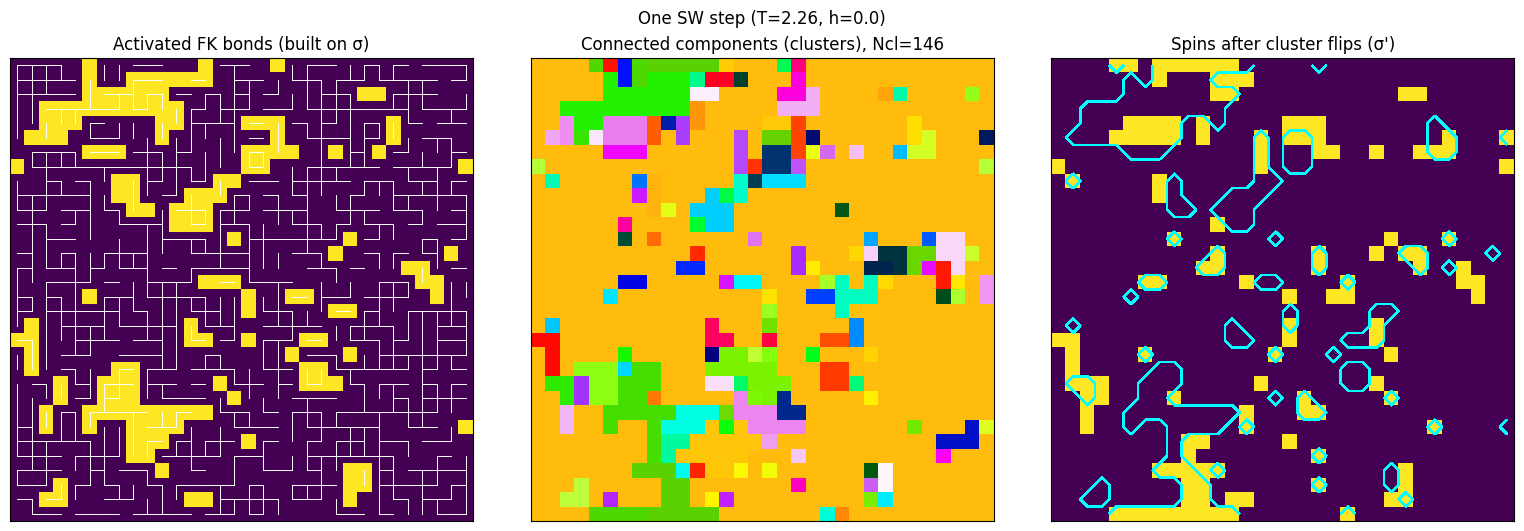

[plot_sw_step] active_nn: 1104/2048 (shown 1069, max 5000)
[plot_sw_step] active_g sites: 152
[plot_sw_step] flipped sites: 57/1024
[plot_sw_step] sanity mismatch = 0


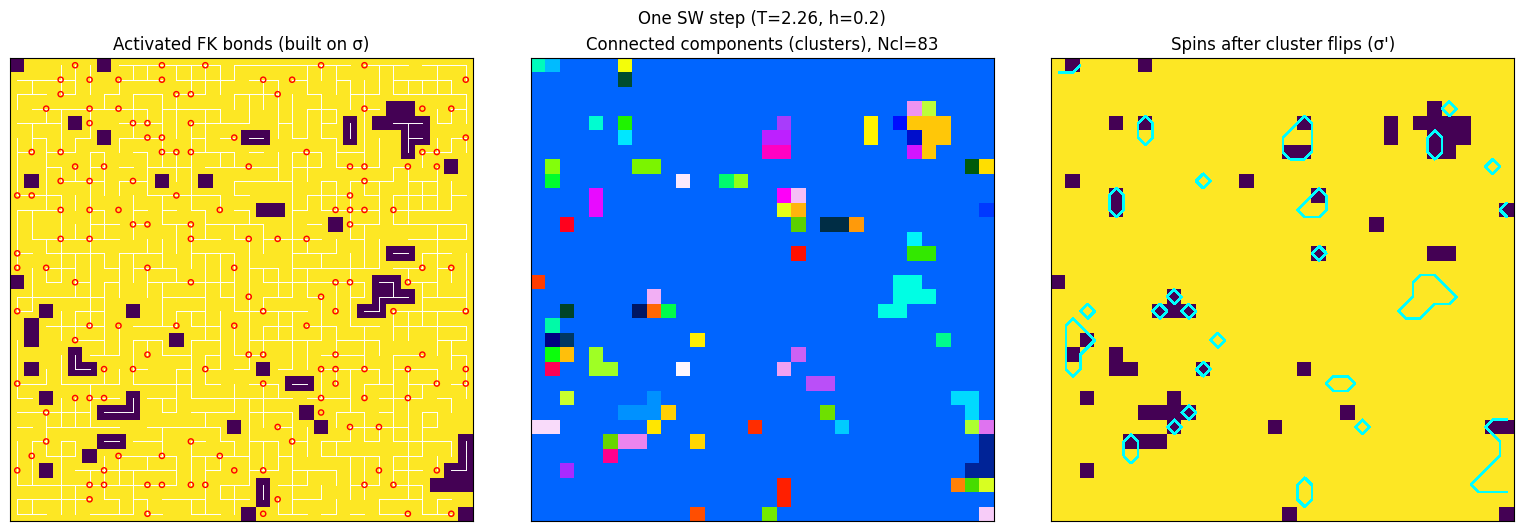

In [11]:
def plot_sw_step(
    spins_before: np.ndarray,
    spins_after: np.ndarray,
    Lx: int,
    Ly: int,
    bonds: np.ndarray,
    active_nn: np.ndarray,
    labels_phys: np.ndarray,
    active_g: np.ndarray | None = None,
    flipped_mask: np.ndarray | None = None,
    title: str = "",
    max_lines: int = 5000,
    cluster_cmap_name: str = "gist_ncar",
    max_cluster_colors: int = 256,
    shuffle_cluster_colors: bool = True,
    cluster_color_seed: int = 0,
    debug: bool = False,
) -> None:

    N = spins_before.size
    assert spins_after.size == N
    assert labels_phys.size == N
    assert bonds.shape[0] == active_nn.size
    if flipped_mask is not None:
        assert flipped_mask.size == N
    if active_g is not None:
        assert active_g.size == N

    fig, axes = plt.subplots(1, 3, figsize=(15.6, 5.2), constrained_layout=True)

    # (1) active bonds + ghost sites
    ax = axes[0]
    ax.imshow(spins_before.reshape(Lx, Ly), vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title("Activated FK bonds (built on σ)")
    ax.set_xticks([]); ax.set_yticks([])

    active_count = int(active_nn.sum())
    shown = 0

    for (a, b), on in zip(bonds, active_nn):
        if not on:
            continue

        xa, ya = divmod(int(a), Ly)
        xb, yb = divmod(int(b), Ly)

        # keep it readable: skip wrap-around edges always
        if (abs(xa - xb) > 1) or (abs(ya - yb) > 1):
            continue

        ax.plot([ya, yb], [xa, xb], color="w", linewidth=0.7, zorder=2)

        shown += 1
        if shown >= max_lines:
            break

    # ghost-connected sites
    gcount = 0
    if active_g is not None and np.any(active_g):
        gi = np.where(active_g)[0]
        gx = gi // Ly
        gy = gi % Ly
        ax.scatter(
            gy, gx,
            s=14, marker="o",
            facecolors="none",
            edgecolors="r",
            linewidths=1.0,
            zorder=3
        )
        gcount = gi.size

    # (2) clusters
    ax = axes[1]
    uniq = np.unique(labels_phys)
    n_clusters = uniq.size

    mapping = {lab: k for k, lab in enumerate(uniq)}
    lab_mapped = np.vectorize(mapping.get)(labels_phys).astype(int)

    n_colors = min(max_cluster_colors, n_clusters)
    base = mpl.colormaps[cluster_cmap_name].resampled(n_colors)
    colors = base(np.arange(n_colors))

    if shuffle_cluster_colors and n_colors > 1:
        rng = np.random.default_rng(cluster_color_seed)
        colors = colors[rng.permutation(n_colors)]

    cmap = ListedColormap(colors)
    img = (lab_mapped % n_colors).reshape(Lx, Ly)

    ax.imshow(img, interpolation="nearest", cmap=cmap)
    ax.set_title(f"Connected components (clusters), Ncl={n_clusters}")
    ax.set_xticks([]); ax.set_yticks([])

    # (3) flipped contour
    ax = axes[2]
    ax.imshow(spins_after.reshape(Lx, Ly), vmin=-1, vmax=1, interpolation="nearest")
    ax.set_title("Spins after cluster flips (σ')")
    ax.set_xticks([]); ax.set_yticks([])

    if flipped_mask is not None:
        fm2 = flipped_mask.reshape(Lx, Ly)
        ax.contour(
            fm2.astype(float),
            levels=[0.5],
            colors=["cyan"],
            linewidths=1.1,
            antialiased=False,
        )

    if debug:
        print(f"[plot_sw_step] active_nn: {active_count}/{active_nn.size} (shown {shown}, max {max_lines})")
        print(f"[plot_sw_step] active_g sites: {gcount if active_g is not None else 'None'}")
        if flipped_mask is not None:
            flipped_count = int(flipped_mask.sum())
            mismatch = int(np.count_nonzero((spins_after != spins_before) != flipped_mask))
            print(f"[plot_sw_step] flipped sites: {flipped_count}/{N}")
            print(f"[plot_sw_step] sanity mismatch = {mismatch}")

    if title:
        fig.suptitle(title)

    plt.show()


def demo_sw_visualization(Lx=32, Ly=32, T=2.26, h=0.2, seed=0, n_therm=200, debug=False):
    bonds = build_bonds(Lx, Ly)
    rng = np.random.default_rng(seed)
    beta = 1.0 / T

    spins = init_spins(Lx * Ly, rng, init="random")
    for _ in range(n_therm):
        spins = sw_update_with_ghost(spins, bonds, beta, rng, J=1.0, h=h)

    spins_after, info = sw_update_with_ghost(spins, bonds, beta, rng, J=1.0, h=h, return_details=True)

    plot_sw_step(
        spins_before=spins,
        spins_after=spins_after,
        Lx=Lx, Ly=Ly,
        bonds=bonds,
        active_nn=info["active_nn"],
        labels_phys=info["labels"][:Lx * Ly],
        active_g=(info["active_g"] if h != 0.0 else None),
        flipped_mask=info["flipped"],
        title=f"One SW step (T={T}, h={h})",
        debug=debug,
        shuffle_cluster_colors=True,
        cluster_color_seed=0,
    )


demo_sw_visualization(h=0.0, seed=0, debug=True)
demo_sw_visualization(h=0.2, seed=0, debug=True)

## Autocorrelation and efficiency of MCMC

Both Metropolis and Swendsen–Wang generate a Markov chain of spin configurations
distributed according to the same Boltzmann weight. Therefore, long-time averages
(e.g. ⟨e⟩ and ⟨|m|⟩) must agree within statistical errors.

However, consecutive configurations are generally correlated. Near the critical point,
local updates suffer from *critical slowing down*: the chain explores configuration
space very slowly and the number of effectively independent measurements is much smaller
than the raw number of Monte Carlo samples.

### Normalized autocorrelation function

For an observable time series $x_t$ we define the normalized autocorrelation function
$$
\rho_x(\delta)=
\frac{\langle x_{t+\delta}x_t\rangle_t-\langle x_t\rangle_t^2}
{\langle x_t^2\rangle_t-\langle x_t\rangle_t^2},
\qquad
\rho_x(0)=1.
$$

### Integrated autocorrelation time and effective sample size

A standard summary of correlations is the *integrated autocorrelation time*
(truncated at a window $W$):
$$
\tau_{\mathrm{int}}(W)=\frac12+\sum_{\delta=1}^{W}\rho(\delta).
$$

The effective number of independent samples is approximately
$$
N_{\mathrm{eff}}\approx \frac{N}{2\tau_{\mathrm{int}}},
$$
and the standard error of the mean increases as
$$
\sigma_{\bar x}\approx \sqrt{\frac{2\tau_{\mathrm{int}}\ \mathrm{Var}(x)}{N}}.
$$

To choose a stable cutoff we use the self-consistent window prescription (Sokal):
$$
W \approx c\,\tau_{\mathrm{int}}(W),\quad c\simeq 5,
$$
which avoids summing deep into the noisy tail of $\rho(\delta)$.

### Performance metric (independent samples per second)

To compare algorithms fairly we measure both (i) decorrelation and (ii) wall-clock time.
For each run we record the measurement time $t_{\mathrm{wall}}$ and define
$$
R=\frac{N_{\mathrm{eff}}}{t_{\mathrm{wall}}}
$$
as the rate of effectively independent samples per second.
A speedup estimate is then
$$
S=\frac{R_{\mathrm{SW}}}{R_{\mathrm{Met}}}.
$$


In [12]:
def autocorr_fft(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    n = x.size
    if n < 2:
        return np.ones(n)

    y = x - x.mean()

    # zero-padding to avoid circular convolution artifacts
    nfft = 1 << (2*n - 1).bit_length()

    f = np.fft.rfft(y, n=nfft)
    ac = np.fft.irfft(f * np.conj(f), n=nfft)[:n]

    # unbiased normalization: divide by number of pairs (n-delta)
    ac /= np.arange(n, 0, -1, dtype=float)

    if ac[0] == 0.0:
        return np.zeros(n)

    return ac / ac[0]


def tau_int_sokal(rho: np.ndarray, c: float = 5.0, max_window: int | None = None) -> tuple[float, int]:
    rho = np.asarray(rho, dtype=float)
    n = rho.size
    if n < 2:
        return 0.5, 0

    if max_window is None:
        max_window = n - 1
    max_window = int(min(max_window, n - 1))

    # start with a small window
    W = min(10, max_window)
    tau = 0.5 + rho[1:W+1].sum()

    for _ in range(80):  # safety cap
        W_new = int(min(max_window, np.floor(c * tau)))
        W_new = max(W_new, 1)

        tau_new = 0.5 + rho[1:W_new+1].sum()

        if abs(W_new - W) <= 1:
            return float(tau_new), int(W_new)

        W, tau = W_new, tau_new

    return float(tau), int(W)


def effective_sample_size(n: int, tau_int: float) -> float:
    return float(n) if tau_int <= 0 else float(n / (2.0 * tau_int))


def stderr_of_mean(x: np.ndarray, tau_int: float) -> float:
    x = np.asarray(x, dtype=float)
    n = x.size
    if n < 2:
        return 0.0
    var = x.var(ddof=1)
    return float(np.sqrt(2.0 * tau_int * var / n))


def analyze_series(x: np.ndarray, name: str, c: float = 5.0, max_lag_plot: int = 300, do_plot: bool = True):
    rho = autocorr_fft(x)
    tau, W = tau_int_sokal(rho, c=c)

    neff = effective_sample_size(len(x), tau)
    se = stderr_of_mean(x, tau)

    if do_plot:
        L = min(max_lag_plot, len(rho) - 1)
        lags = np.arange(L + 1)

        plt.figure(figsize=(6.8, 4.2))
        plt.plot(lags, rho[:L+1], marker="o", markersize=3, linewidth=1.0)
        plt.axhline(0.0, linewidth=1.0)
        plt.xlabel(r"$\delta$")
        plt.ylabel(rf"$\rho_{{{name}}}(\delta)$")
        plt.title(rf"{name}: $\tau_{{int}} \approx {tau:.2f}$ (W={W}), $N_{{eff}}\approx {neff:.0f}$")
        plt.tight_layout()
        plt.show()

    return {
        "rho": rho,
        "tau_int": tau,
        "W": W,
        "N_eff": neff,
        "stderr_mean": se,
        "mean": float(np.mean(x)),
        "var": float(np.var(x, ddof=1)) if len(x) > 1 else 0.0,
    }

In [ ]:
def analyze_series_stats(x: np.ndarray, c: float = 5.0) -> dict:
    rho = autocorr_fft(x)
    tau, W = tau_int_sokal(rho, c=c)
    neff = effective_sample_size(len(x), tau)
    se = stderr_of_mean(x, tau)
    return {
        "rho": rho,
        "tau": float(tau),
        "W": int(W),
        "N_eff": float(neff),
        "stderr": float(se),
        "mean": float(np.mean(x)),
    }

def summarize_run(run: dict, c: float = 5.0) -> dict:
    outE = analyze_series_stats(run["E"], c=c)
    outM = analyze_series_stats(run["abs_m"], c=c)

    beta = float(run["beta"])
    N = int(run["N"])

    Cv = heat_capacity_from_series(run["E_raw"], beta=beta, N=N)
    # chi = susceptibility_phase_fixed_from_series(run["M_raw"], run["absM_raw"], beta=beta, N=N)
    chi = susceptibility_from_series(run["M_raw"], beta=beta, N=N)

    t = float(run.get("wall_time_meas_s", np.nan))
    n = int(run.get("n_meas", len(run["E"])))

    rateE = outE["N_eff"] / t if (t == t and t > 0) else np.nan
    rateM = outM["N_eff"] / t if (t == t and t > 0) else np.nan

    return {
        "algo": run["algo"],
        "T": float(run["T"]),
        "beta": beta,
        "N": N,
        "n_meas": n,
        "wall_time_meas_s": t,

        "tauint_e": outE["tau"],
        "tauint_abs_m": outM["tau"],

        "Neff_per_s_e": float(rateE),
        "Neff_per_s_abs_m": float(rateM),

        "mean_e": outE["mean"],
        "stderr_e": outE["stderr"],
        "mean_abs_m": outM["mean"],
        "stderr_abs_m": outM["stderr"],

        "Cv": Cv,
        "chi": chi,

        # keep for plotting overlays
        "rho_e": outE["rho"],
        "rho_abs_m": outM["rho"],
        "W_e": outE["W"],
        "W_abs_m": outM["W"],
    }

def print_summary_table(rows: list[dict]):
    cols = [
        "algo","T","n_meas","wall_time_meas_s",
        "mean_e","stderr_e","tauint_e",
        "mean_abs_m","stderr_abs_m","tauint_abs_m",
        "Cv","chi",
        "Neff_per_s_e","Neff_per_s_abs_m",
    ]
    header = " | ".join([f"{c:>16s}" for c in cols])
    print(header)
    print("-"*len(header))
    for r in rows:
        line = []
        for c in cols:
            v = r[c]
            if c == "algo":
                line.append(f"{v:>16s}")
            else:
                line.append(f"{v:16.4g}")
        print(" | ".join(line))

def plot_acf_two_panels(rhos_e: dict, rhos_m: dict, max_lag: int = 300, suptitle: str = ""):
    fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6), constrained_layout=True)

    # energy
    ax = axes[0]
    for label, rho in rhos_e.items():
        L = min(max_lag, len(rho) - 1)
        ax.plot(np.arange(L+1), rho[:L+1], linewidth=1.0, label=label)
    ax.axhline(0.0, linewidth=1.0)
    ax.set_xlabel(r"$\delta$")
    ax.set_ylabel(r"$\rho_e(\delta)$")
    ax.set_title("Energy ACF")
    ax.legend(fontsize=8)

    # |m|
    ax = axes[1]
    for label, rho in rhos_m.items():
        L = min(max_lag, len(rho) - 1)
        ax.plot(np.arange(L+1), rho[:L+1], linewidth=1.0, label=label)
    ax.axhline(0.0, linewidth=1.0)
    ax.set_xlabel(r"$\delta$")
    ax.set_ylabel(r"$\rho_{|m|}(\delta)$")
    ax.set_title(r"$|m|$ ACF")
    ax.legend(fontsize=8)

    if suptitle:
        fig.suptitle(suptitle)
    plt.show()

def compare_algorithms_at_temperatures(
    temps: list[float],
    Lx: int, Ly: int,
    n_therm_met: int, n_meas_met: int,
    n_therm_sw: int,  n_meas_sw: int,
    seed: int = 0,
    h: float = 0.0,
    c: float = 5.0,
):
    bonds = build_bonds(Lx, Ly)
    nbrs  = build_neighbours(Lx, Ly)

    runs = {}
    summaries = []
    for T in temps:
        met = run_metropolis(
            T=T, bonds=bonds, nbrs=nbrs,
            n_therm=n_therm_met, n_meas=n_meas_met,
            init="random", seed=seed, h=h
        )
        sw  = run_sw(
            T=T, bonds=bonds, Lx=Lx, Ly=Ly,
            n_therm=n_therm_sw, n_meas=n_meas_sw,
            init="random", seed=seed, h=h
        )

        runs[(T, "met")] = met
        runs[(T, "sw")]  = sw

        summaries.append(summarize_run(met, c=c))
        summaries.append(summarize_run(sw,  c=c))

    return summaries, runs

def plot_acf_met_vs_sw_for_T(runs: dict, T: float, max_lag: int = 300, c: float = 5.0):
    met_sum = summarize_run(runs[(T, "met")], c=c)
    sw_sum  = summarize_run(runs[(T, "sw")],  c=c)

    rhos_e = {
        f"Metropolis (τ={met_sum['tauint_e']:.1f})": met_sum["rho_e"],
        f"Swendsen-Wang (τ={sw_sum['tauint_e']:.1f})": sw_sum["rho_e"],
    }
    rhos_m = {
        f"Metropolis (τ={met_sum['tauint_abs_m']:.1f})": met_sum["rho_abs_m"],
        f"Swendsen-Wang (τ={sw_sum['tauint_abs_m']:.1f})": sw_sum["rho_abs_m"],
    }
    plot_acf_two_panels(rhos_e, rhos_m, max_lag=max_lag, suptitle=f"ACF at T={T:.3f} (h=0)")

def plot_acf_off_critical(runs: dict, T_list: list[float], max_lag: int = 300, c: float = 5.0):
    rhos_e = {}
    rhos_m = {}
    for T in T_list:
        met_sum = summarize_run(runs[(T, "met")], c=c)
        sw_sum  = summarize_run(runs[(T, "sw")],  c=c)

        rhos_e[f"T={T:.3f} Met (τ={met_sum['tauint_e']:.1f})"] = met_sum["rho_e"]
        rhos_e[f"T={T:.3f} SW  (τ={sw_sum['tauint_e']:.1f})"]  = sw_sum["rho_e"]

        rhos_m[f"T={T:.3f} Met (τ={met_sum['tauint_abs_m']:.1f})"] = met_sum["rho_abs_m"]
        rhos_m[f"T={T:.3f} SW  (τ={sw_sum['tauint_abs_m']:.1f})"]  = sw_sum["rho_abs_m"]

    plot_acf_two_panels(rhos_e, rhos_m, max_lag=max_lag, suptitle="ACF off criticality (h=0)")

def print_speedup_table(summaries: list[dict]):
    header = " | ".join([f"{c:>12s}" for c in ["T", "S_e", "S_|m|", "rate_met_e", "rate_sw_e", "rate_met_|m|", "rate_sw_|m|"]])
    print(header)
    print("-"*len(header))

    for k in range(0, len(summaries), 2):
        met = summaries[k]
        sw  = summaries[k+1]
        T = met["T"]

        S_e = sw["Neff_per_s_e"] / met["Neff_per_s_e"]
        S_m = sw["Neff_per_s_abs_m"] / met["Neff_per_s_abs_m"]

        print(" | ".join([
            f"{T:12.4g}",
            f"{S_e:12.4g}",
            f"{S_m:12.4g}",
            f"{met['Neff_per_s_e']:12.4g}",
            f"{sw['Neff_per_s_e']:12.4g}",
            f"{met['Neff_per_s_abs_m']:12.4g}",
            f"{sw['Neff_per_s_abs_m']:12.4g}",
        ]))

            algo |                T |           n_meas | wall_time_meas_s |           mean_e |         stderr_e |         tauint_e |       mean_abs_m |     stderr_abs_m |     tauint_abs_m |               Cv |              chi |     Neff_per_s_e | Neff_per_s_abs_m
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
      metropolis |              2.1 |             6000 |            19.91 |           -1.663 |         0.002079 |            3.135 |           0.8692 |         0.002095 |            7.348 |             0.96 |           0.8732 |            48.07 |            20.51
              sw |              2.1 |             6000 |            1.369 |           -1.663 |         0.001841 |            2.424 |           0.8702 |         0.001171 |             2.23 |            0.974 |

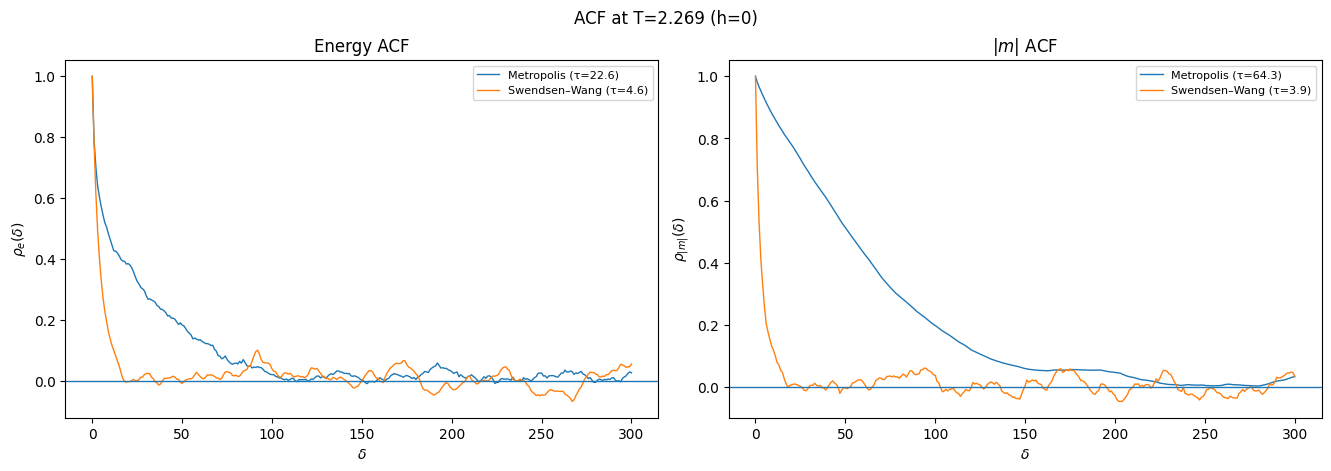

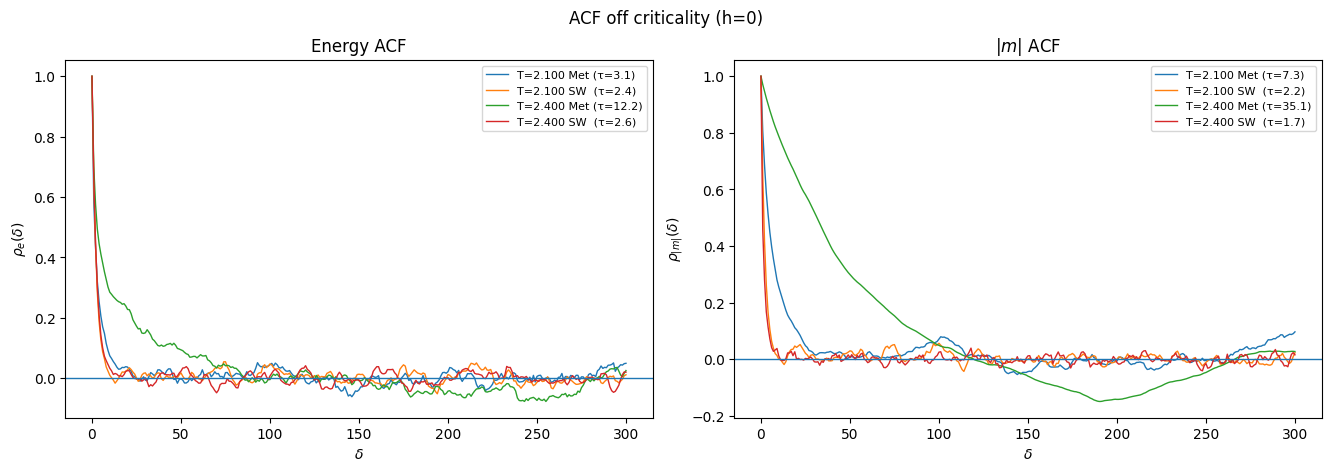

In [14]:
Lx, Ly = 32, 32
temps = [2.10, 2.269, 2.40]

summaries, runs = compare_algorithms_at_temperatures(
    temps=temps,
    Lx=Lx, Ly=Ly,
    n_therm_met=3000, n_meas_met=6000,
    n_therm_sw=800,   n_meas_sw=6000,
    seed=0,
    h=0.0,
    c=5.0
)

print_summary_table(summaries)
print("\nSpeedup (based on N_eff / wall time):")
print_speedup_table(summaries)

plot_acf_met_vs_sw_for_T(runs, T=2.269, max_lag=300, c=5.0)
plot_acf_off_critical(runs, T_list=[2.10, 2.40], max_lag=300, c=5.0)

## Dynamic critical scaling: $\tau_{\mathrm{int}}(L)$ and critical slowing down

The key signature of critical slowing down is that, at (or very close to) $T_c$,
the autocorrelation time grows with system size. This is typically described by
the dynamic scaling law

$$
\tau(L) \propto L^z,
$$

where $z$ is the *dynamic critical exponent* and depends on the update algorithm.
Local updates (Metropolis) have relatively large $z$ (slow decorrelation),
while cluster algorithms (Swendsen–Wang) strongly reduce $z$.

We estimate $z$ by fitting a straight line in log–log scale:

$$
\ln \tau(L) = z \ln L + \mathrm{const}.
$$

We focus on $T \approx T_c$ and compare $\tau_{\mathrm{int}}$ for energy density $e$
and magnetization magnitude $|m|$.

In [15]:
def linear_fit_loglog(L_vals, y_vals):
    L_vals = np.asarray(L_vals, dtype=float)
    y_vals = np.asarray(y_vals, dtype=float)

    mask = (L_vals > 0) & (y_vals > 0) & np.isfinite(L_vals) & np.isfinite(y_vals)
    L = L_vals[mask]
    y = y_vals[mask]

    X = np.log(L)
    Y = np.log(y)

    # least squares
    A = np.vstack([np.ones_like(X), X]).T
    a, b = np.linalg.lstsq(A, Y, rcond=None)[0]

    # R^2
    Yhat = a + b * X
    ss_res = np.sum((Y - Yhat) ** 2)
    ss_tot = np.sum((Y - Y.mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return float(b), float(a), float(r2), int(L.size)

def plot_tau_scaling(L_list, tau_met, tau_sw, title, ylabel=r"$\tau_{\mathrm{int}}$"):
    plt.figure(figsize=(6.6, 4.6))
    plt.loglog(L_list, tau_met, marker="o", linewidth=1.2, label="Metropolis")
    plt.loglog(L_list, tau_sw,  marker="o", linewidth=1.2, label="Swendsen–Wang")
    plt.xlabel(r"$L$")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def run_scaling_at_Tc(
    L_list,
    T=2.269,
    n_therm_met_factor=200,   # sweeps
    n_meas_met_factor=400,    # sweeps
    n_therm_sw_factor=50,     # cluster steps
    n_meas_sw_factor=400,     # cluster steps
    seed=0,
    h=0.0,
    c=5.0,
):
    rows = []
    results = {
        "L": [],
        "met_tau_e": [], "sw_tau_e": [],
        "met_tau_m": [], "sw_tau_m": [],
        "met_rate_e": [], "sw_rate_e": [],
        "met_rate_m": [], "sw_rate_m": [],
    }

    for L in L_list:
        Lx = Ly = int(L)
        N = Lx * Ly
        bonds = build_bonds(Lx, Ly)
        nbrs  = build_neighbours(Lx, Ly)

        n_therm_met = int(n_therm_met_factor)
        n_meas_met  = int(n_meas_met_factor)

        n_therm_sw  = int(n_therm_sw_factor)
        n_meas_sw   = int(n_meas_sw_factor)

        met = run_metropolis(
            T=T, bonds=bonds, nbrs=nbrs,
            n_therm=n_therm_met, n_meas=n_meas_met,
            init="random", seed=seed, h=h
        )
        sw = run_sw(
            T=T, bonds=bonds, Lx=Lx, Ly=Ly,
            n_therm=n_therm_sw, n_meas=n_meas_sw,
            init="random", seed=seed, h=h
        )

        sm_met = summarize_run(met, c=c)
        sm_sw  = summarize_run(sw,  c=c)

        results["L"].append(L)
        results["met_tau_e"].append(sm_met["tauint_e"])
        results["sw_tau_e"].append(sm_sw["tauint_e"])
        results["met_tau_m"].append(sm_met["tauint_abs_m"])
        results["sw_tau_m"].append(sm_sw["tauint_abs_m"])

        results["met_rate_e"].append(sm_met["Neff_per_s_e"])
        results["sw_rate_e"].append(sm_sw["Neff_per_s_e"])
        results["met_rate_m"].append(sm_met["Neff_per_s_abs_m"])
        results["sw_rate_m"].append(sm_sw["Neff_per_s_abs_m"])

        rows.append({
            "algo": "metropolis", "T": T, "L": L, "n_meas": sm_met["n_meas"], "wall_time_meas_s": sm_met["wall_time_meas_s"],
            "tauint_e": sm_met["tauint_e"], "tauint_abs_m": sm_met["tauint_abs_m"],
            "Neff_per_s_e": sm_met["Neff_per_s_e"], "Neff_per_s_abs_m": sm_met["Neff_per_s_abs_m"],
            "mean_e": sm_met["mean_e"], "stderr_e": sm_met["stderr_e"],
            "mean_abs_m": sm_met["mean_abs_m"], "stderr_abs_m": sm_met["stderr_abs_m"],
        })
        rows.append({
            "algo": "sw", "T": T, "L": L, "n_meas": sm_sw["n_meas"], "wall_time_meas_s": sm_sw["wall_time_meas_s"],
            "tauint_e": sm_sw["tauint_e"], "tauint_abs_m": sm_sw["tauint_abs_m"],
            "Neff_per_s_e": sm_sw["Neff_per_s_e"], "Neff_per_s_abs_m": sm_sw["Neff_per_s_abs_m"],
            "mean_e": sm_sw["mean_e"], "stderr_e": sm_sw["stderr_e"],
            "mean_abs_m": sm_sw["mean_abs_m"], "stderr_abs_m": sm_sw["stderr_abs_m"],
        })

    return results, rows

def print_scaling_table(rows):
    cols = ["algo","L","T","n_meas","wall_time_meas_s","tauint_e","tauint_abs_m","Neff_per_s_e","Neff_per_s_abs_m"]
    header = " | ".join([f"{c:>14s}" for c in cols])
    print(header)
    print("-"*len(header))
    for r in rows:
        print(" | ".join([
            f"{r['algo']:>14s}",
            f"{r['L']:14.4g}",
            f"{r['T']:14.4g}",
            f"{r['n_meas']:14.4g}",
            f"{r['wall_time_meas_s']:14.4g}",
            f"{r['tauint_e']:14.4g}",
            f"{r['tauint_abs_m']:14.4g}",
            f"{r['Neff_per_s_e']:14.4g}",
            f"{r['Neff_per_s_abs_m']:14.4g}",
        ]))


          algo |              L |              T |         n_meas | wall_time_meas_s |       tauint_e |   tauint_abs_m |   Neff_per_s_e | Neff_per_s_abs_m
----------------------------------------------------------------------------------------------------------------------------------------------------------
    metropolis |             16 |          2.269 |           6000 |          5.067 |          6.489 |          13.97 |          91.24 |          42.37
            sw |             16 |          2.269 |           6000 |         0.9259 |          3.562 |           2.98 |          909.7 |           1087
    metropolis |             24 |          2.269 |           6000 |          11.28 |          23.93 |          53.32 |          11.12 |           4.99
            sw |             24 |          2.269 |           6000 |           1.09 |          4.097 |          3.458 |          671.6 |          795.8
    metropolis |             32 |          2.269 |           6000 |          20.34 |  

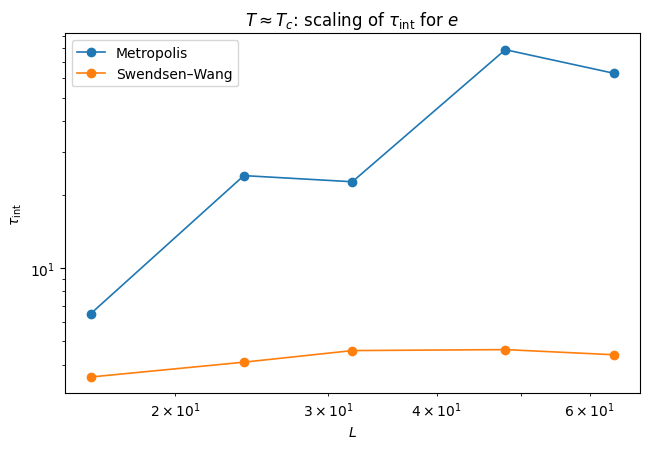

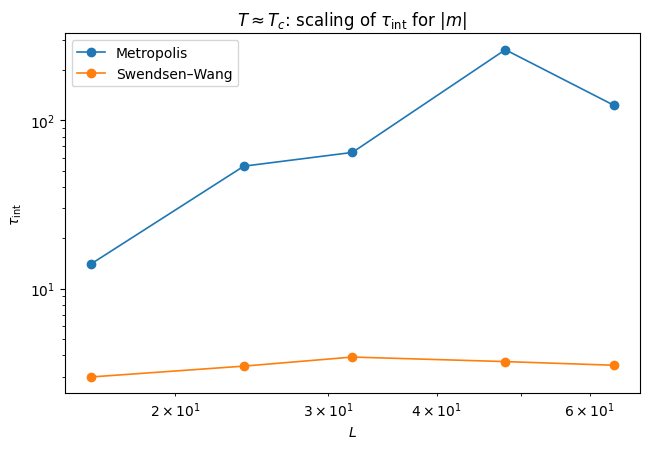

Estimated dynamic exponents z from tau_int(L) ~ L^z at T ~ Tc
Energy:    Metropolis z = 1.692 (R^2=0.877),  SW z = 0.158 (R^2=0.658)
|m|:       Metropolis z = 1.760 (R^2=0.789),  SW z = 0.112 (R^2=0.371)


In [16]:
L_list = [16, 24, 32, 48, 64]
T = 2.269

results, rows = run_scaling_at_Tc(
    L_list=L_list,
    T=T,
    n_therm_met_factor=3000,
    n_meas_met_factor=6000,
    n_therm_sw_factor=800,
    n_meas_sw_factor=6000,
    seed=0,
    h=0.0,
    c=5.0,
)

print_scaling_table(rows)

L = np.array(results["L"], dtype=float)

met_tau_e = np.array(results["met_tau_e"], dtype=float)
sw_tau_e  = np.array(results["sw_tau_e"], dtype=float)

met_tau_m = np.array(results["met_tau_m"], dtype=float)
sw_tau_m  = np.array(results["sw_tau_m"], dtype=float)

plot_tau_scaling(L, met_tau_e, sw_tau_e, title=rf"$T \approx T_c$: scaling of $\tau_{{\mathrm{{int}}}}$ for $e$")
plot_tau_scaling(L, met_tau_m, sw_tau_m, title=rf"$T \approx T_c$: scaling of $\tau_{{\mathrm{{int}}}}$ for $|m|$")

# Fit dynamic exponent z from log-log
z_met_e, a_met_e, r2_met_e, n_met_e = linear_fit_loglog(L, met_tau_e)
z_sw_e,  a_sw_e,  r2_sw_e,  n_sw_e  = linear_fit_loglog(L, sw_tau_e)

z_met_m, a_met_m, r2_met_m, n_met_m = linear_fit_loglog(L, met_tau_m)
z_sw_m,  a_sw_m,  r2_sw_m,  n_sw_m  = linear_fit_loglog(L, sw_tau_m)

print("Estimated dynamic exponents z from tau_int(L) ~ L^z at T ~ Tc")
print(f"Energy:    Metropolis z = {z_met_e:.3f} (R^2={r2_met_e:.3f}),  SW z = {z_sw_e:.3f} (R^2={r2_sw_e:.3f})")
print(f"|m|:       Metropolis z = {z_met_m:.3f} (R^2={r2_met_m:.3f}),  SW z = {z_sw_m:.3f} (R^2={r2_sw_m:.3f})")

## Main result: critical slowing down vs cluster dynamics

Away from $T_c$, both Metropolis and Swendsen–Wang decorrelate quickly and yield compatible averages for
$e$ and $|m|$. The difference becomes dramatic near criticality, where the correlation length grows
to the system size.

For Metropolis, updates are local. Near $T_c$ large domains reorganize only through slow motion of domain walls,
which leads to critical slowing down: the integrated autocorrelation time increases strongly with $L$.
In contrast, Swendsen–Wang builds Fortuin–Kasteleyn clusters and flips them non-locally. At $T_c$ this matches
the physical large-scale correlations and keeps $\tau_{\mathrm{int}}$ nearly constant as $L$ increases.

Combining decorrelation and runtime via $R=N_{\mathrm{eff}}/t_{\mathrm{wall}}$, we find speedups of
orders of magnitude near $T_c$, showing that cluster algorithms effectively remove critical slowing down in practice.


## Thermodynamics from fluctuations: $C_V(T)$ and $\chi(T)$

From the Monte Carlo time series we compute thermodynamic response functions via fluctuation relations:
$$
C_V = \frac{\beta^2}{N}\left(\langle E^2\rangle - \langle E\rangle^2\right),\qquad
\chi = \frac{\beta}{N}\left(\langle M^2\rangle - \langle M\rangle^2\right).
$$

These quantities provide a physics cross-check: both Metropolis and Swendsen–Wang must reproduce the same equilibrium
curves (within statistical errors). The peak structures around the exact $T_c$ reflect enhanced fluctuations and
large correlation lengths near criticality (rounded and finite due to finite system size).

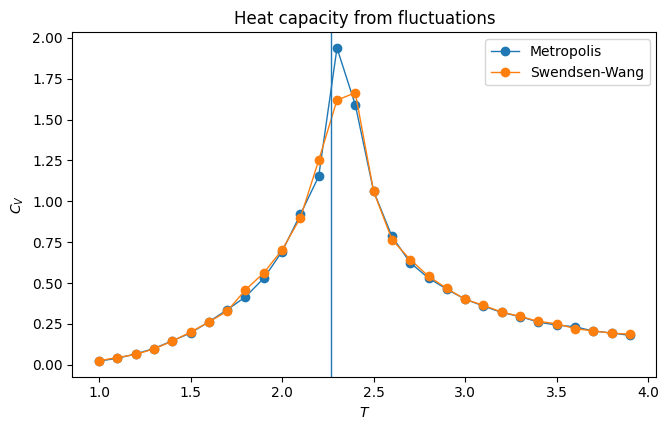

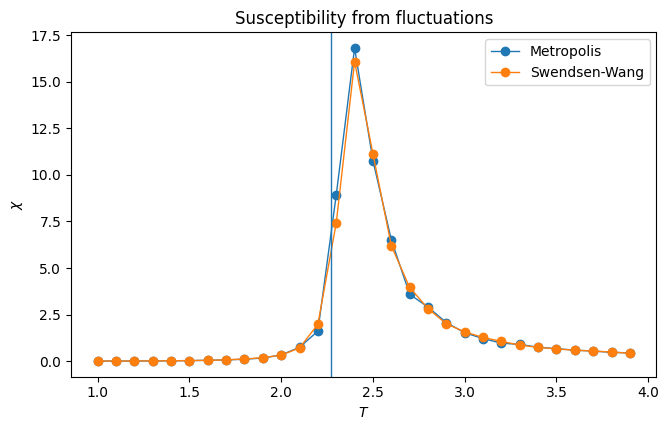

In [ ]:
Lx = Ly = 32
temps = np.arange(1.0, 4.0, 0.1)

summaries, runs = compare_algorithms_at_temperatures(
    temps=temps,
    Lx=Lx, Ly=Ly,
    n_therm_met=3500, n_meas_met=8000,
    n_therm_sw=1000,   n_meas_sw=8000,
    seed=0,
    h=0.0,
    c=5.0
)

T_met, Cv_met, chi_met = [], [], []
T_sw,  Cv_sw,  chi_sw  = [], [], []

for r in summaries:
    if r["algo"] == "metropolis":
        T_met.append(r["T"])
        Cv_met.append(r["Cv"])
        chi_met.append(r["chi"])
    else:
        T_sw.append(r["T"])
        Cv_sw.append(r["Cv"])
        chi_sw.append(r["chi"])

# (1) Cv(T)
plt.figure(figsize=(6.8, 4.4))
plt.plot(T_met, Cv_met, marker="o", linewidth=1.0, label="Metropolis")
plt.plot(T_sw,  Cv_sw,  marker="o", linewidth=1.0, label="Swendsen-Wang")
plt.axvline(2.269, linewidth=1.0)
plt.xlabel(r"$T$")
plt.ylabel(r"$C_V$")
plt.title(r"Heat capacity from fluctuations")
plt.legend()
plt.tight_layout()
plt.show()

# (2) chi(T)
plt.figure(figsize=(6.8, 4.4))
plt.plot(T_met, chi_met, marker="o", linewidth=1.0, label="Metropolis")
plt.plot(T_sw,  chi_sw,  marker="o", linewidth=1.0, label="Swendsen-Wang")
plt.axvline(2.269, linewidth=1.0)
plt.xlabel(r"$T$")
plt.ylabel(r"$\chi$")
plt.title(r"Susceptibility from fluctuations")
plt.legend()
plt.tight_layout()
plt.show()

# Quantum Transverse-Field Ising Chain  
## From a Quantum 1D Model to a Classical 2D System

In this part of the project we study the one-dimensional quantum Ising model in a transverse field and show how it can be simulated using classical Monte Carlo methods.

The key idea is that the quantum partition function can be mapped onto a classical anisotropic 2D Ising model using Suzuki–Trotter decomposition.

---

## 1. The Quantum Model

We consider the transverse-field Ising chain:

$$
H = -J \sum_{j=0}^{L-1} \sigma^z_j \sigma^z_{j+1}
    - g \sum_{j=0}^{L-1} \sigma^x_j.
$$

- $J$ favors alignment in the $z$ direction.
- $g$ introduces quantum fluctuations via spin flips.
- $\sigma^z$ and $\sigma^x$ do not commute:

$$
[\sigma^z, \sigma^x] \neq 0,
$$

so this is a genuinely quantum system.

At zero temperature:

- For small $g$: ordered phase (ferromagnetic in $z$).
- For large $g$: quantum disordered phase.
- The quantum critical point occurs at $g_c = J$.

---

## 2. Quantum Statistical Mechanics

The partition function is

$$
Z = \mathrm{Tr}(e^{-\beta H}),
$$

which cannot be evaluated directly because $H_z$ and $H_x$ do not commute.

We split:

$$
H = H_z + H_x,
$$

with

$$
H_z = -J \sum_j \sigma^z_j \sigma^z_{j+1}, 
\qquad
H_x = -g \sum_j \sigma^x_j.
$$

---

## 3. Suzuki–Trotter Decomposition

We use

$$
e^{-\beta H}
\approx
\left(e^{-\Delta\tau H_z} e^{-\Delta\tau H_x}\right)^M,
\quad
\Delta\tau = \frac{\beta}{M}.
$$

As $M \to \infty$, this becomes exact.

The integer $M$ introduces an additional direction:  
**imaginary time**.

So instead of a 1D quantum chain, we now obtain a 2D classical system of size:

$$
L \times M.
$$

---

## 4. Classical Mapping

After inserting complete sets in the $\sigma^z$ basis, the partition function becomes

$$
Z \propto \sum_{\{s_{j,\tau}\}}
\exp\left(
K_s \sum_{j,\tau} s_{j,\tau}s_{j+1,\tau}
+
K_\tau \sum_{j,\tau} s_{j,\tau}s_{j,\tau+1}
\right).
$$

This is a classical anisotropic 2D Ising model.

The couplings are:

$$
K_s = \frac{\beta J}{M},
$$

$$
K_\tau = \frac{1}{2} \ln \coth\left(\frac{\beta g}{M}\right).
$$

Interpretation:

- Spatial direction ($j$): original lattice.
- Trotter direction ($\tau$): imaginary time.
- Quantum fluctuations become couplings along $\tau$.

## Detailed derivation: Suzuki–Trotter mapping to an anisotropic 2D Ising model

<details>
<summary><b>Detailed derivaiton</b></summary>

### A. Starting point: transverse-field Ising chain

We consider
$$
H = H_z + H_x,
\qquad
H_z = -J\sum_{j=0}^{L-1}\sigma^z_j\sigma^z_{j+1},
\qquad
H_x = -g\sum_{j=0}^{L-1}\sigma^x_j,
$$
and the quantum partition function
$$
Z = \mathrm{Tr}\left(e^{-\beta H}\right).
$$

The difficulty is that $[H_z,H_x]\neq 0$.

---

### B. Suzuki–Trotter decomposition

Using the (first-order) Trotter formula,
$$
e^{-\beta(H_z+H_x)}
\approx
\left(e^{-\Delta\tau H_z}e^{-\Delta\tau H_x}\right)^M,
\qquad
\Delta\tau=\frac{\beta}{M},
$$
so that
$$
Z \approx \mathrm{Tr}\left[\left(e^{-\Delta\tau H_z}e^{-\Delta\tau H_x}\right)^M\right].
$$

The approximation becomes exact for $M\to\infty$ (i.e. $\Delta\tau\to 0$).

---

### C. Insert complete sets in the $\sigma^z$ basis

Let $|s\rangle$ denote a $\sigma^z$-eigenstate, labeled by classical spins
$$
s_j=\pm 1,
\qquad
\sigma^z_j|s\rangle = s_j|s\rangle.
$$

Insert identities between all Trotter factors:
$$
\mathbf{1}=\sum_{s(\tau)} |s(\tau)\rangle\langle s(\tau)|.
$$

Then
$$
Z \approx \sum_{\{s(0),\dots,s(M-1)\}}
\prod_{\tau=0}^{M-1}
\langle s(\tau)|e^{-\Delta\tau H_z}|s(\tau)\rangle
\;
\langle s(\tau)|e^{-\Delta\tau H_x}|s(\tau+1)\rangle.
$$

Because of the trace, we identify the final slice with the initial one:
$$
s(M)=s(0),
$$
which is the origin of periodic boundary conditions in imaginary time.

---

### D. Spatial coupling from $H_z$ (diagonal part)

Since $H_z$ is diagonal in the $\sigma^z$ basis:
$$
\langle s(\tau)|e^{-\Delta\tau H_z}|s(\tau)\rangle
=
\exp\!\left(+\Delta\tau J\sum_{j=0}^{L-1} s_{j,\tau}s_{j+1,\tau}\right).
$$

Define the spatial coupling
$$
K_s = \Delta\tau J = \frac{\beta J}{M}.
$$

So the diagonal part yields nearest-neighbor couplings along the spatial direction on each Trotter slice.

---

### E. Imaginary-time coupling from $H_x$ (off-diagonal part)

We need the matrix element
$$
\langle s(\tau)|e^{-\Delta\tau H_x}|s(\tau+1)\rangle
=
\prod_{j=0}^{L-1}
\langle s_{j,\tau}| e^{+\Delta\tau g\,\sigma^x} | s_{j,\tau+1}\rangle,
$$
because $H_x=-g\sum_j\sigma^x_j$ and different sites factorize.

For one spin we use
$$
e^{a\sigma^x}=\cosh(a)\,\mathbf{1}+\sinh(a)\,\sigma^x,
\qquad a=\Delta\tau g.
$$

In the $\sigma^z$ basis,
- if $s=s'$:
$$
\langle s|e^{a\sigma^x}|s\rangle=\cosh(a),
$$
- if $s\neq s'$:
$$
\langle s|e^{a\sigma^x}|-s\rangle=\sinh(a).
$$

Now we rewrite these two weights in the Ising form
$$
\langle s|e^{a\sigma^x}|s'\rangle = A \, e^{K_\tau ss'},
\qquad s,s'=\pm 1,
$$
so that the ratio of equal/unequal cases matches:
$$
\frac{\cosh(a)}{\sinh(a)} = \frac{A e^{K_\tau}}{A e^{-K_\tau}} = e^{2K_\tau}.
$$

Therefore
$$
K_\tau = \frac12 \ln\coth(a)
       = \frac12 \ln\coth\!\left(\frac{\beta g}{M}\right).
$$

(The overall factor $A=\sqrt{\cosh(a)\sinh(a)}$ only multiplies $Z$ by a constant and is irrelevant for normalized expectation values.)

---

### F. Final classical 2D anisotropic Ising model

Combining both contributions,
$$
Z \propto \sum_{\{s_{j,\tau}=\pm 1\}}
\exp\left(
K_s \sum_{\tau,j} s_{j,\tau}s_{j+1,\tau}
+
K_\tau \sum_{\tau,j} s_{j,\tau}s_{j,\tau+1}
\right),
$$
with couplings
$$
K_s = \frac{\beta J}{M},
\qquad
K_\tau = \frac12 \ln\coth\!\left(\frac{\beta g}{M}\right).
$$

Interpretation:
- index $j$ is the original spatial site,
- index $\tau$ is the Trotter (imaginary-time) slice,
- quantum fluctuations from $g$ become classical correlations along $\tau$.

---

### G. Geometry

- The trace enforces periodicity in imaginary time:
$$
s_{j,M}=s_{j,0}.
$$

- If we also impose periodic boundary conditions in space:
$$
s_{L,\tau}=s_{0,\tau},
$$
then the lattice is periodic in both directions ⇒ topologically a torus.

If space is open but imaginary time is periodic, the geometry is a cylinder.

</details>

---

## 5. Geometry of Imaginary Time

The lattice is:

- periodic in space,
- periodic in imaginary time (because of the trace).

Thus the geometry is a torus.

Each site carries a classical spin:

$$
s_{j,\tau} = \pm 1.
$$

The quantum problem becomes a classical statistical problem in one higher dimension.

---

## 6. What Are Worldlines?

When we visualize the configuration $s_{j,\tau}$:

- vertical axis → spatial index $j$
- horizontal axis → imaginary time $\tau$

Each horizontal line corresponds to a fixed Trotter slice.
Each vertical line corresponds to a fixed spatial site.

A “worldline” is the sequence:

$$
\{ s_{j,\tau} \}_{\tau=0}^{M-1}
$$

It shows how a quantum spin evolves in imaginary time.

---

### Ordered phase (small $g$)

- Worldlines are mostly straight.
- Spins remain aligned along imaginary time.
- Strong correlation in both directions.
- Large $m_z$.

This corresponds to ferromagnetic order in the quantum model.

---

### Disordered phase (large $g$)

- Frequent flips along imaginary time.
- Worldlines fluctuate strongly.
- Correlation in $\tau$ direction weakens.
- Small $m_z$.

This corresponds to a quantum paramagnet.

---

## 7. Physical Interpretation of the Mapping

The transverse field $g$ produces quantum tunneling between $+z$ and $-z$ states.

In the classical picture this appears as:

- Strong coupling in $\tau$ direction for small $g$
- Weaker coupling for large $g$

Thus:

Quantum fluctuations ↔ imaginary-time coupling strength.

At large $\beta$ (low temperature), the system approaches the ground-state quantum phase transition at $g_c \approx J$.

---

## 8. Observables

In the classical simulation:

$$
m_z =
\left\langle
\frac{1}{LM}
\sum_{j,\tau} s_{j,\tau}
\right\rangle.
$$

This equals the quantum expectation value:

$$
\langle \sigma^z \rangle.
$$

The curves $\langle |m_z| \rangle (g)$ show:

- Smooth crossover at finite $\beta$
- Sharpening toward a quantum phase transition as $\beta$ increases

---

## 9. Trotter Convergence

Increasing $M$ improves the approximation:

$$
\Delta\tau = \frac{\beta}{M}.
$$

If curves for $M=64$ and $M=128$ coincide within errors,
the Trotter discretization error is under control.

In [33]:
def build_bonds_2d_aniso(L: int, M: int):
    N = L * M
    bi = np.empty(2 * N, dtype=np.int32)
    bj = np.empty(2 * N, dtype=np.int32)
    bdir = np.empty(2 * N, dtype=np.int8)

    k = 0
    for j in range(L):
        for tau in range(M):
            n = j * M + tau

            # +space bond
            n_s = ((j + 1) % L) * M + tau
            bi[k] = n
            bj[k] = n_s
            bdir[k] = 0
            k += 1

            # +trotter bond
            n_t = j * M + ((tau + 1) % M)
            bi[k] = n
            bj[k] = n_t
            bdir[k] = 1
            k += 1

    return bi, bj, bdir, N


def sw_sweep_qmc(
    spins: np.ndarray,
    bi: np.ndarray,
    bj: np.ndarray,
    bdir: np.ndarray,
    p_space: float,
    p_tau: float,
    rng: np.random.Generator
) -> int:
    # choose p bond-by-bond depending on direction
    p = np.where(bdir == 0, p_space, p_tau)

    # activate only if parallel
    parallel = (spins[bi] == spins[bj])
    active = parallel & (rng.random(size=bi.size) < p)

    rows = bi[active]
    cols = bj[active]
    data = np.ones(rows.size, dtype=np.int8)

    # connected components on active-bond graph
    A = csr_matrix((data, (rows, cols)), shape=(spins.size, spins.size))
    A = A + A.T

    n_comp, labels = connected_components(A, directed=False)

    # flip each cluster independently with prob 1/2
    flip = rng.random(n_comp) < 0.5
    spins[flip[labels]] *= -1

    return int(n_comp)


def run_qmc(
    L: int,
    M: int,
    beta: float,
    J: float,
    g: float,
    n_therm: int,
    n_meas: int,
    seed: int = 0
) -> dict:
    rng = np.random.default_rng(seed)

    # Couplings of the effective classical anisotropic 2D Ising model
    Ks = beta * J / M

    x = beta * g / M
    # Guard against x -> 0 causing tanh(x) ~ 0
    x = max(float(x), 1e-12)
    Ktau = 0.5 * np.log(1.0 / np.tanh(x))  # = 0.5 ln coth(x)

    # FK bond probabilities for anisotropic couplings
    p_space = 1.0 - np.exp(-2.0 * Ks)
    p_tau   = 1.0 - np.exp(-2.0 * Ktau)

    bi, bj, bdir, N = build_bonds_2d_aniso(L, M)

    spins = rng.choice([-1, 1], size=N).astype(np.int8)

    # thermalization (cluster sweeps)
    for _ in range(n_therm):
        sw_sweep_qmc(spins, bi, bj, bdir, p_space, p_tau, rng)

    # measurement
    mz = np.empty(n_meas, dtype=float)
    ncl = np.empty(n_meas, dtype=np.int32)

    for t in range(n_meas):
        ncl[t] = sw_sweep_qmc(spins, bi, bj, bdir, p_space, p_tau, rng)
        m_slice = spins.reshape(L, M).mean(axis=0)   # magnetization per time-slice
        mz[t] = abs(m_slice.mean())                 # average over tau, then abs

    return {
        "mz": mz,
        "n_clusters": ncl,
        "Ks": float(Ks),
        "Ktau": float(Ktau),
        "p_space": float(p_space),
        "p_tau": float(p_tau),
        "L": int(L),
        "M": int(M),
        "beta": float(beta),
        "J": float(J),
        "g": float(g),
        "n_meas": int(n_meas),
        "algo": "sw_aniso",
        "spins_final": spins.copy()
    }
    
def plot_two_worldlines(spins1, spins2, L, M, title1="", title2=""):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

    im0 = axes[0].imshow(spins1.reshape(L, M), aspect="auto",
                         interpolation="nearest", vmin=-1, vmax=1)
    axes[0].set_xlabel(r"Trotter slice $\tau$")
    axes[0].set_ylabel(r"site $j$")
    axes[0].set_title(title1)

    im1 = axes[1].imshow(spins2.reshape(L, M), aspect="auto",
                         interpolation="nearest", vmin=-1, vmax=1)
    axes[1].set_xlabel(r"Trotter slice $\tau$")
    axes[1].set_ylabel(r"site $j$")
    axes[1].set_title(title2)

    cbar = fig.colorbar(im1, ax=axes, shrink=0.85)
    cbar.remove()
    plt.show()

      g |    <|m_z|> ± SE         | tau_int (W) |       Ks     Ktau |      p_s    p_tau
------------------------------------------------------------------------------------------
  0.200 |     0.9017 ± 0.0047     |    1.56 ( 7) |  0.03125   2.5376 |   0.0606   0.9938
  0.457 |     0.7946 ± 0.0055     |    1.45 ( 7) |  0.03125   2.1243 |   0.0606   0.9857
  0.714 |     0.5942 ± 0.0057     |    1.30 ( 6) |  0.03125   1.9012 |   0.0606   0.9777
  0.971 |     0.4187 ± 0.0042     |    0.96 ( 4) |  0.03125   1.7475 |   0.0606   0.9697
  1.229 |     0.2844 ± 0.0028     |    0.76 ( 3) |  0.03125   1.6302 |   0.0606   0.9616
  1.486 |     0.2087 ± 0.0020     |    0.68 ( 3) |  0.03125   1.5353 |   0.0606   0.9536
  1.743 |     0.1642 ± 0.0015     |    0.60 ( 3) |  0.03125   1.4556 |   0.0606   0.9456
  2.000 |     0.1376 ± 0.0013     |    0.62 ( 3) |  0.03125   1.3869 |   0.0606   0.9376


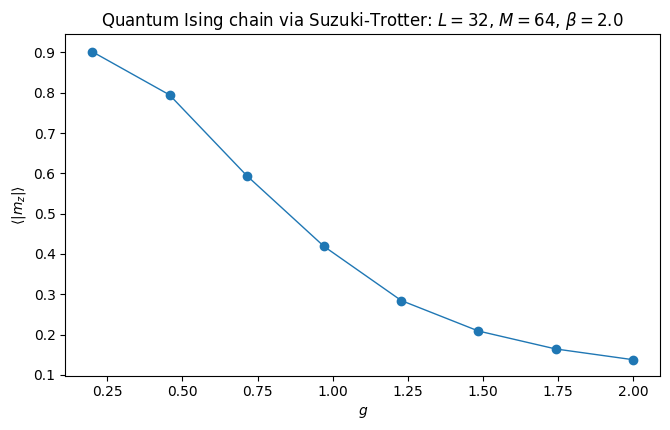

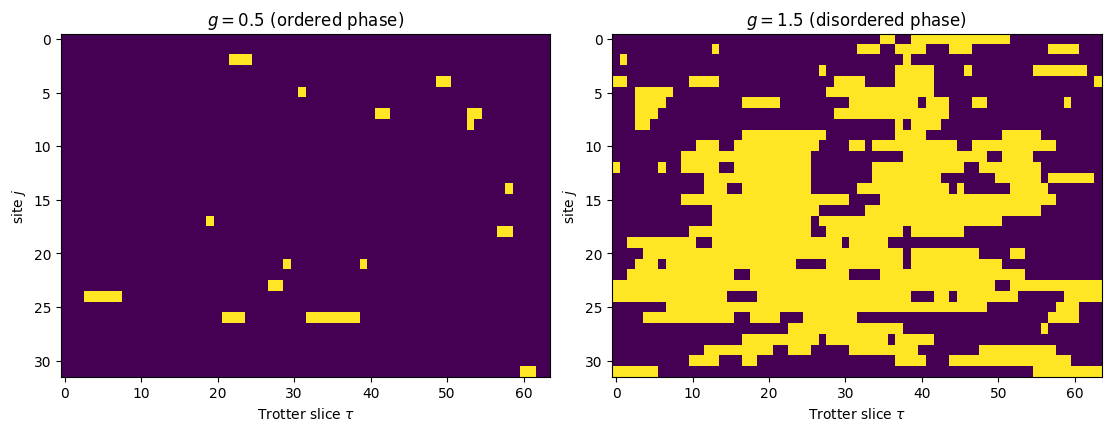

In [34]:
def mean_and_stderr_mcmc(x: np.ndarray, c: float = 5.0):
    x = np.asarray(x, dtype=float)
    rho = autocorr_fft(x)
    tau, W = tau_int_sokal(rho, c=c)
    se = stderr_of_mean(x, tau)
    return float(x.mean()), float(se), float(tau), int(W)

L = 32
beta = 2.0
J = 1.0

g_values = np.linspace(0.2, 2.0, 8)

M = 64  # baseline Trotter number
means, errors, taus = [], [], []

print(f"{'g':>7s} | {'<|m_z|>':>10s} ± {'SE':<10s} | {'tau_int':>7s} (W) | {'Ks':>8s} {'Ktau':>8s} | {'p_s':>8s} {'p_tau':>8s}")
print("-"*90)

for g in g_values:
    out = run_qmc(L, M, beta, J, g, n_therm=1500, n_meas=8000, seed=0)
    mu, se, tau, W = mean_and_stderr_mcmc(out["mz"], c=5.0)

    means.append(mu)
    errors.append(se)
    taus.append(tau)

    print(
        f"{g:7.3f} | "
        f"{mu:10.4f} ± {se:<10.4f} | "
        f"{tau:7.2f} ({W:2d}) | "
        f"{out['Ks']:8.5f} {out['Ktau']:8.4f} | "
        f"{out['p_space']:8.4f} {out['p_tau']:8.4f}"
    )

plt.figure(figsize=(6.8, 4.4))
plt.errorbar(g_values, means, yerr=errors, marker="o", linewidth=1.0)
plt.xlabel(r"$g$")
plt.ylabel(r"$\langle |m_z| \rangle$")
plt.title(rf"Quantum Ising chain via Suzuki-Trotter: $L={L}$, $M={M}$, $\beta={beta}$")
plt.tight_layout()
plt.show()

out1 = run_qmc(L=32, M=64, beta=6.0, J=1.0, g=0.5,
               n_therm=2000, n_meas=2000, seed=0)

out2 = run_qmc(L=32, M=64, beta=6.0, J=1.0, g=1.5,
               n_therm=2000, n_meas=2000, seed=0)

plot_two_worldlines(
    out1["spins_final"],
    out2["spins_final"],
    32, 64,
    title1=r"$g=0.5$ (ordered phase)",
    title2=r"$g=1.5$ (disordered phase)"
)

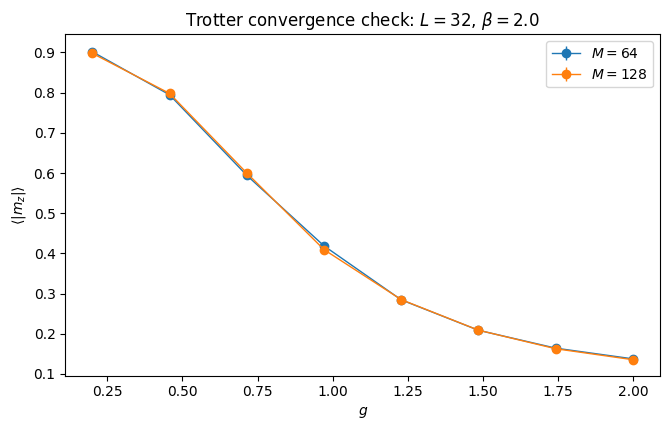

In [23]:
L = 32
beta = 2.0
J = 1.0
g_values = np.linspace(0.2, 2.0, 8)

Ms = [64, 128]
curves = {}

for M in Ms:
    means, errors = [], []
    for g in g_values:
        out = run_qmc(L, M, beta, J, g, n_therm=1500, n_meas=8000, seed=0)
        mu, se, tau, W = mean_and_stderr_mcmc(out["mz"], c=5.0)
        means.append(mu)
        errors.append(se)
    curves[M] = (np.array(means), np.array(errors))

plt.figure(figsize=(6.8, 4.4))
for M in Ms:
    means, errors = curves[M]
    plt.errorbar(g_values, means, yerr=errors, marker="o", linewidth=1.0, label=rf"$M={M}$")
plt.xlabel(r"$g$")
plt.ylabel(r"$\langle |m_z| \rangle$")
plt.title(rf"Trotter convergence check: $L={L}$, $\beta={beta}$")
plt.legend()
plt.tight_layout()
plt.show()


=== beta = 1.0 ===
g= 0.200  <|m_z|>= 0.3904 ±  0.0033   tau_int≈ 0.72
g= 0.364  <|m_z|>= 0.3795 ±  0.0030   tau_int≈ 0.67
g= 0.527  <|m_z|>= 0.3604 ±  0.0029   tau_int≈ 0.67
g= 0.691  <|m_z|>= 0.3379 ±  0.0027   tau_int≈ 0.63
g= 0.855  <|m_z|>= 0.3158 ±  0.0025   tau_int≈ 0.63
g= 1.018  <|m_z|>= 0.2901 ±  0.0023   tau_int≈ 0.64
g= 1.182  <|m_z|>= 0.2604 ±  0.0020   tau_int≈ 0.59
g= 1.345  <|m_z|>= 0.2422 ±  0.0019   tau_int≈ 0.58
g= 1.509  <|m_z|>= 0.2175 ±  0.0017   tau_int≈ 0.58
g= 1.673  <|m_z|>= 0.2070 ±  0.0016   tau_int≈ 0.57
g= 1.836  <|m_z|>= 0.1898 ±  0.0016   tau_int≈ 0.62
g= 2.000  <|m_z|>= 0.1743 ±  0.0014   tau_int≈ 0.57

=== beta = 2.0 ===
g= 0.200  <|m_z|>= 0.9026 ±  0.0042   tau_int≈ 1.63
g= 0.364  <|m_z|>= 0.8455 ±  0.0048   tau_int≈ 1.58
g= 0.527  <|m_z|>= 0.7530 ±  0.0053   tau_int≈ 1.54
g= 0.691  <|m_z|>= 0.6237 ±  0.0053   tau_int≈ 1.38
g= 0.855  <|m_z|>= 0.4860 ±  0.0045   tau_int≈ 1.16
g= 1.018  <|m_z|>= 0.3847 ±  0.0035   tau_int≈ 0.92
g= 1.182  <|m_z|>= 0.304

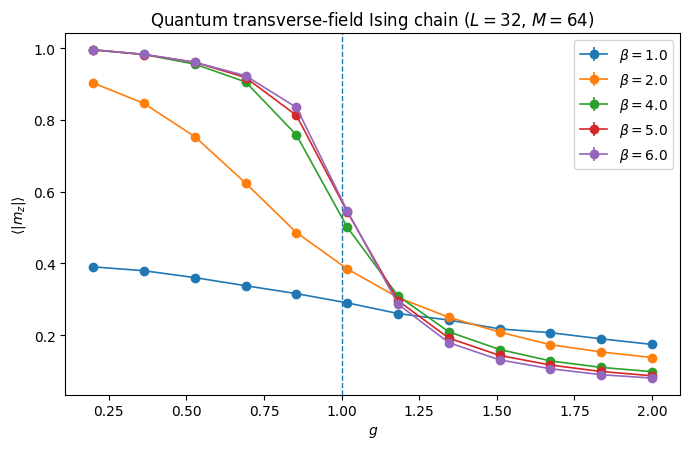

In [26]:
L = 32
J = 1.0
M = 64

g_values = np.linspace(0.2, 2.0, 12)

betas = [1.0, 2.0, 4.0, 5.0, 6.0]
curves = {}

for beta in betas:
    means, errors = [], []
    
    print(f"\n=== beta = {beta} ===")
    
    for g in g_values:
        out = run_qmc(
            L=L, M=M,
            beta=beta, J=J, g=g,
            n_therm=2000,
            n_meas=10000,
            seed=0
        )
        
        mu, se, tau, W = mean_and_stderr_mcmc(out["mz"], c=5.0)
        
        means.append(mu)
        errors.append(se)
        
        print(f"g={g: .3f}  <|m_z|>={mu: .4f} ± {se: .4f}   tau_int≈{tau: .2f}")
    
    curves[beta] = (np.array(means), np.array(errors))


plt.figure(figsize=(7.0, 4.6))

for beta in betas:
    means, errors = curves[beta]
    plt.errorbar(
        g_values,
        means,
        yerr=errors,
        marker="o",
        linewidth=1.2,
        label=rf"$\beta={beta}$"
    )

plt.axvline(1.0, linestyle="--", linewidth=1.0)
plt.xlabel(r"$g$")
plt.ylabel(r"$\langle |m_z| \rangle$")
plt.title(rf"Quantum transverse-field Ising chain ($L={L}$, $M={M}$)")
plt.legend()
plt.tight_layout()
plt.show()